# Import Librairy

In [1]:
import os
import psycopg2
import json
import git
import pandas as pd

# aggre_tran

In [2]:
path1 = "C:/Users/lenovo/Prime_Classes/LabmentixProject/ThirdProject/pulse/data/aggregated/transaction/country/india/state"

In [3]:
columns = {
    "States": [],
    "Years": [],
    "Quarter": [],
    "Transaction_type": [],
    "Transaction_count": [],
    "Transaction_amount": []
}

In [4]:
agg_tran_list = os.listdir(path1)

In [5]:
for state in agg_tran_list:
    cur_state = os.path.join(path1, state)

    if not os.path.isdir(cur_state):
        continue

    for year in os.listdir(cur_state):
        cur_year = os.path.join(cur_state, year)

        for file in os.listdir(cur_year):
            cur_file = os.path.join(cur_year, file)

            try:
                with open(cur_file, "r") as f:
                    data = json.load(f)

                # Extract quarter correctly
                quarter = int(file.replace(".json", ""))

                # 🔥 SAFE extraction (VERY IMPORTANT)
                if data.get("data") and data["data"].get("transactionData"):

                    for i in data["data"]["transactionData"]:
                        name = i["name"]

                        for j in i["paymentInstruments"]:
                            columns["States"].append(state)
                            columns["Years"].append(int(year))
                            columns["Quarter"].append(quarter)
                            columns["Transaction_type"].append(name)
                            columns["Transaction_count"].append(j["count"])
                            columns["Transaction_amount"].append(j["amount"])

            except Exception as e:
                print("Error:", cur_file, e)

In [6]:
agg_tran = pd.DataFrame(columns)
print(agg_tran.head())

                      States  Years  Quarter          Transaction_type  \
0  andaman-&-nicobar-islands   2018        1  Recharge & bill payments   
1  andaman-&-nicobar-islands   2018        1     Peer-to-peer payments   
2  andaman-&-nicobar-islands   2018        1         Merchant payments   
3  andaman-&-nicobar-islands   2018        1        Financial Services   
4  andaman-&-nicobar-islands   2018        1                    Others   

   Transaction_count  Transaction_amount  
0               4200        1.845307e+06  
1               1871        1.213866e+07  
2                298        4.525072e+05  
3                 33        1.060142e+04  
4                256        1.846899e+05  


In [7]:
agg_tran

,States,Years,Quarter,Transaction_type,Transaction_count,Transaction_amount
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05
...,...,...,...,...,...,...
5029,west-bengal,2024,4,Merchant payments,655100809,3.892862e+11
5030,west-bengal,2024,4,Peer-to-peer payments,493217788,1.361927e+12
5031,west-bengal,2024,4,Recharge & bill payments,76043195,5.753406e+10
5032,west-bengal,2024,4,Financial Services,2352084,8.472965e+08


In [8]:
agg_tran["States"] = agg_tran["States"].str.replace("andaman-&-nicobar-islands","Andaman & Nicobar")
agg_tran["States"] = agg_tran["States"].str.replace("-"," ")
agg_tran["States"] = agg_tran["States"].str.title()
agg_tran['States'] = agg_tran['States'].str.replace("Dadra & Nagar Haveli & Daman & Diu", "Dadra and Nagar Haveli and Daman and Diu")

In [9]:
agg_tran

,States,Years,Quarter,Transaction_type,Transaction_count,Transaction_amount
0,Andaman & Nicobar,2018,1,Recharge & bill payments,4200,1.845307e+06
1,Andaman & Nicobar,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,Andaman & Nicobar,2018,1,Merchant payments,298,4.525072e+05
3,Andaman & Nicobar,2018,1,Financial Services,33,1.060142e+04
4,Andaman & Nicobar,2018,1,Others,256,1.846899e+05
...,...,...,...,...,...,...
5029,West Bengal,2024,4,Merchant payments,655100809,3.892862e+11
5030,West Bengal,2024,4,Peer-to-peer payments,493217788,1.361927e+12
5031,West Bengal,2024,4,Recharge & bill payments,76043195,5.753406e+10
5032,West Bengal,2024,4,Financial Services,2352084,8.472965e+08


# User_aggre

In [10]:
path2 = "C:/Users/lenovo/Prime_Classes/LabmentixProject/ThirdProject/pulse/data/aggregated/user/country/india/state"

In [11]:
agg_user_list = os.listdir(path2)

In [12]:
columns2 = {
    "States": [],
    "Years": [],
    "Quarter": [],
    "Brands": [],
    "Transaction_count": [],
    "Percentage": []
}

In [13]:
for state in agg_user_list:
    cur_states=os.path.join(path2,state)
    agg_year_list = os.listdir(cur_states)

    for year in agg_year_list:
        cur_year = os.path.join(cur_states,year)
        agg_file_list = os.listdir(cur_year)

        for file in agg_file_list:
            cur_file = os.path.join(cur_year,file)
            data = open(cur_file, "r")

            B = json.load(data)
            
            try:
                for i in B["data"]["usersByDevice"]:
                    brand = i["brand"]
                    count = i["count"]
                    percentage = i["percentage"]
                    columns2["Brands"].append(brand)
                    columns2["Transaction_count"].append(count)
                    columns2["Percentage"].append(percentage)
                    columns2["States"].append(state)
                    columns2["Years"].append(year)
                    columns2["Quarter"].append(int(file.strip(".json")))

            except:
                pass
        

In [14]:
aggre_user = pd.DataFrame(columns2)

In [15]:
aggre_user

,States,Years,Quarter,Brands,Transaction_count,Percentage
0,andaman-&-nicobar-islands,2018,1,Xiaomi,1665,0.247033
1,andaman-&-nicobar-islands,2018,1,Samsung,1445,0.214392
2,andaman-&-nicobar-islands,2018,1,Vivo,982,0.145697
3,andaman-&-nicobar-islands,2018,1,Oppo,501,0.074332
4,andaman-&-nicobar-islands,2018,1,OnePlus,332,0.049258
...,...,...,...,...,...,...
6727,west-bengal,2022,1,Lenovo,330017,0.015056
6728,west-bengal,2022,1,Infinix,284678,0.012987
6729,west-bengal,2022,1,Asus,280347,0.012790
6730,west-bengal,2022,1,Apple,277752,0.012671


In [16]:
aggre_user["States"] = aggre_user["States"].str.replace("andaman-&-nicobar-islands","Andaman & Nicobar")
aggre_user["States"] = aggre_user["States"].str.replace("-"," ")
aggre_user["States"] = aggre_user["States"].str.title()
aggre_user['States'] = aggre_user['States'].str.replace("Dadra & Nagar Haveli & Daman & Diu", "Dadra and Nagar Haveli and Daman and Diu")

In [17]:
aggre_user

,States,Years,Quarter,Brands,Transaction_count,Percentage
0,Andaman & Nicobar,2018,1,Xiaomi,1665,0.247033
1,Andaman & Nicobar,2018,1,Samsung,1445,0.214392
2,Andaman & Nicobar,2018,1,Vivo,982,0.145697
3,Andaman & Nicobar,2018,1,Oppo,501,0.074332
4,Andaman & Nicobar,2018,1,OnePlus,332,0.049258
...,...,...,...,...,...,...
6727,West Bengal,2022,1,Lenovo,330017,0.015056
6728,West Bengal,2022,1,Infinix,284678,0.012987
6729,West Bengal,2022,1,Asus,280347,0.012790
6730,West Bengal,2022,1,Apple,277752,0.012671


# map_tran

In [18]:
path3 = "C:/Users/lenovo/Prime_Classes/LabmentixProject/ThirdProject/pulse/data/map/transaction/hover/country/india/state/"

In [19]:
map_tran_list = os.listdir(path3)

In [20]:
columns3 = {
    "States": [],
    "Years": [],
    "Quarter": [],
    "District":[],
    "Transaction_count": [],
    "Transaction_amount":[]
}

In [21]:
for state in map_tran_list:
    cur_states = path3+state+"/"
    map_year_list = os.listdir(cur_states)
    
    for year in map_year_list:
        cur_years = cur_states+year+"/"
        map_file_list = os.listdir(cur_years)
        
        for file in map_file_list:
            cur_files = cur_years+file
            data = open(cur_files,"r")
            C = json.load(data)
            
            for i in C ['data']["hoverDataList"]:
                name = i["name"]
                count = i["metric"][0]["count"]
                amount = i["metric"][0]["amount"]
                columns3["District"].append(name)
                columns3["Transaction_count"].append(count)
                columns3["Transaction_amount"].append(amount)
                columns3["States"].append(state)
                columns3["Years"].append(year)
                columns3["Quarter"].append(int(file.strip(".json")))

In [22]:
map_transaction = pd.DataFrame(columns3)

In [23]:
map_transaction

,States,Years,Quarter,District,Transaction_count,Transaction_amount
0,andaman-&-nicobar-islands,2018,1,north and middle andaman district,442,9.316631e+05
1,andaman-&-nicobar-islands,2018,1,south andaman district,5688,1.256025e+07
2,andaman-&-nicobar-islands,2018,1,nicobars district,528,1.139849e+06
3,andaman-&-nicobar-islands,2018,2,north and middle andaman district,825,1.317863e+06
4,andaman-&-nicobar-islands,2018,2,south andaman district,9395,2.394824e+07
...,...,...,...,...,...,...
20599,west-bengal,2024,4,alipurduar district,15875637,2.099251e+10
20600,west-bengal,2024,4,paschim bardhaman district,56616799,6.968735e+10
20601,west-bengal,2024,4,nadia district,65274337,1.079320e+11
20602,west-bengal,2024,4,birbhum district,36905213,5.778701e+10


In [24]:
map_transaction["States"] = map_transaction["States"].str.replace("andaman-&-nicobar-islands","Andaman & Nicobar")
map_transaction["States"] = map_transaction["States"].str.replace("-"," ")
map_transaction["States"] = map_transaction["States"].str.title()
map_transaction['States'] = map_transaction['States'].str.replace("Dadra & Nagar Haveli & Daman & Diu", "Dadra and Nagar Haveli and Daman and Diu")

In [25]:
map_transaction

,States,Years,Quarter,District,Transaction_count,Transaction_amount
0,Andaman & Nicobar,2018,1,north and middle andaman district,442,9.316631e+05
1,Andaman & Nicobar,2018,1,south andaman district,5688,1.256025e+07
2,Andaman & Nicobar,2018,1,nicobars district,528,1.139849e+06
3,Andaman & Nicobar,2018,2,north and middle andaman district,825,1.317863e+06
4,Andaman & Nicobar,2018,2,south andaman district,9395,2.394824e+07
...,...,...,...,...,...,...
20599,West Bengal,2024,4,alipurduar district,15875637,2.099251e+10
20600,West Bengal,2024,4,paschim bardhaman district,56616799,6.968735e+10
20601,West Bengal,2024,4,nadia district,65274337,1.079320e+11
20602,West Bengal,2024,4,birbhum district,36905213,5.778701e+10


In [26]:
map_transaction.isnull().sum()

States                0
Years                 0
Quarter               0
District              0
Transaction_count     0
Transaction_amount    0
dtype: int64

# map_user

In [27]:
path4 = "C:/Users/lenovo/Prime_Classes/LabmentixProject/ThirdProject/pulse/data/map/user/hover/country/india/state/"

In [28]:
map_user_list = os.listdir(path4)

In [29]:
columns4 = {"States":[], 
            "Years":[], 
            "Quarter":[], 
            "Districts":[], 
            "RegisteredUser":[], 
            "AppOpens":[]
           }

In [30]:
for state in map_user_list:
    cur_states = path4+state+"/"
    map_year_list = os.listdir(cur_states)
    
    for year in map_year_list:
        cur_years = cur_states+year+"/"
        map_file_list = os.listdir(cur_years)
        
        for file in map_file_list:
            cur_files = cur_years+file
            data = open(cur_files,"r")
            D = json.load(data)

            for i in D["data"]["hoverData"].items():
                district = i[0]
                registereduser = i[1]["registeredUsers"]
                appopens = i[1]["appOpens"]
                columns4["Districts"].append(district)
                columns4["RegisteredUser"].append(registereduser)
                columns4["AppOpens"].append(appopens)
                columns4["States"].append(state)
                columns4["Years"].append(year)
                columns4["Quarter"].append(int(file.strip(".json")))


In [31]:
map_user = pd.DataFrame(columns4)

In [32]:
map_user

,States,Years,Quarter,Districts,RegisteredUser,AppOpens
0,andaman-&-nicobar-islands,2018,1,north and middle andaman district,632,0
1,andaman-&-nicobar-islands,2018,1,south andaman district,5846,0
2,andaman-&-nicobar-islands,2018,1,nicobars district,262,0
3,andaman-&-nicobar-islands,2018,2,north and middle andaman district,911,0
4,andaman-&-nicobar-islands,2018,2,south andaman district,8143,0
...,...,...,...,...,...,...
20603,west-bengal,2024,4,alipurduar district,475688,31842355
20604,west-bengal,2024,4,paschim bardhaman district,1468252,80543469
20605,west-bengal,2024,4,nadia district,1861738,98740305
20606,west-bengal,2024,4,birbhum district,1114220,73465525


In [33]:
map_user["States"] = map_user["States"].str.replace("andaman-&-nicobar-islands","Andaman & Nicobar")
map_user["States"] = map_user["States"].str.replace("-"," ")
map_user["States"] = map_user["States"].str.title()
map_user['States'] = map_user['States'].str.replace("Dadra & Nagar Haveli & Daman & Diu", "Dadra and Nagar Haveli and Daman and Diu")

In [34]:
map_user

,States,Years,Quarter,Districts,RegisteredUser,AppOpens
0,Andaman & Nicobar,2018,1,north and middle andaman district,632,0
1,Andaman & Nicobar,2018,1,south andaman district,5846,0
2,Andaman & Nicobar,2018,1,nicobars district,262,0
3,Andaman & Nicobar,2018,2,north and middle andaman district,911,0
4,Andaman & Nicobar,2018,2,south andaman district,8143,0
...,...,...,...,...,...,...
20603,West Bengal,2024,4,alipurduar district,475688,31842355
20604,West Bengal,2024,4,paschim bardhaman district,1468252,80543469
20605,West Bengal,2024,4,nadia district,1861738,98740305
20606,West Bengal,2024,4,birbhum district,1114220,73465525


# aggre_insur

In [36]:
path5 = "C:/Users/lenovo/Prime_Classes/LabmentixProject/ThirdProject/pulse/data/aggregated/insurance/country/india/state/"

In [37]:
agg_insur_list= os.listdir(path5)

In [38]:
columns5= {"States":[], "Years":[], "Quarter":[], "Transaction_type":[], "Transaction_count":[],"Transaction_amount":[] }

In [39]:
for state in agg_insur_list:
    cur_states =path5+state+"/"
    agg_year_list = os.listdir(cur_states)
    
    for year in agg_year_list:
        cur_years = cur_states+year+"/"
        agg_file_list = os.listdir(cur_years)

        for file in agg_file_list:
            cur_files = cur_years+file
            data = open(cur_files,"r")
            E = json.load(data)

            for i in E["data"]["transactionData"]:
                name = i["name"]
                count = i["paymentInstruments"][0]["count"]
                amount = i["paymentInstruments"][0]["amount"]
                columns5["Transaction_type"].append(name)
                columns5["Transaction_count"].append(count)
                columns5["Transaction_amount"].append(amount)
                columns5["States"].append(state)
                columns5["Years"].append(year)
                columns5["Quarter"].append(int(file.strip(".json")))

In [105]:
aggre_insurance = pd.DataFrame(columns = columns5)

In [106]:
aggre_insurance

,States,Years,Quarter,Transaction_type,Transaction_count,Transaction_amount
0,andaman-&-nicobar-islands,2020,2,Insurance,6,1360.0
1,andaman-&-nicobar-islands,2020,3,Insurance,41,15380.0
2,andaman-&-nicobar-islands,2020,4,Insurance,124,157975.0
3,andaman-&-nicobar-islands,2021,1,Insurance,225,244266.0
4,andaman-&-nicobar-islands,2021,2,Insurance,137,181504.0
...,...,...,...,...,...,...
677,west-bengal,2023,4,Insurance,72712,100365562.0
678,west-bengal,2024,1,Insurance,79576,104987909.0
679,west-bengal,2024,2,Insurance,67048,89476633.0
680,west-bengal,2024,3,Insurance,77158,107451766.0


In [107]:
aggre_insurance["States"].unique()

array(['andaman-&-nicobar-islands', 'andhra-pradesh', 'arunachal-pradesh',
       'assam', 'bihar', 'chandigarh', 'chhattisgarh',
       'dadra-&-nagar-haveli-&-daman-&-diu', 'delhi', 'goa', 'gujarat',
       'haryana', 'himachal-pradesh', 'jammu-&-kashmir', 'jharkhand',
       'karnataka', 'kerala', 'ladakh', 'lakshadweep', 'madhya-pradesh',
       'maharashtra', 'manipur', 'meghalaya', 'mizoram', 'nagaland',
       'odisha', 'puducherry', 'punjab', 'rajasthan', 'sikkim',
       'tamil-nadu', 'telangana', 'tripura', 'uttar-pradesh',
       'uttarakhand', 'west-bengal'], dtype=object)

In [43]:
aggre_insurance["States"] = aggre_insurance["States"].str.replace("andaman-&-nicobar-islands","Andaman & Nicobar")
aggre_insurance["States"] = aggre_insurance["States"].str.replace("-"," ")
aggre_insurance["States"] = aggre_insurance["States"].str.title()
aggre_insurance['States'] = aggre_insurance['States'].str.replace("Dadra & Nagar Haveli & Daman & Diu", "Dadra and Nagar Haveli and Daman and Diu")

In [44]:
aggre_insurance

,States,Years,Quarter,Transaction_type,Transaction_count,Transaction_amount
0,Andaman & Nicobar,2020,2,Insurance,6,1360.0
1,Andaman & Nicobar,2020,3,Insurance,41,15380.0
2,Andaman & Nicobar,2020,4,Insurance,124,157975.0
3,Andaman & Nicobar,2021,1,Insurance,225,244266.0
4,Andaman & Nicobar,2021,2,Insurance,137,181504.0
...,...,...,...,...,...,...
677,West Bengal,2023,4,Insurance,72712,100365562.0
678,West Bengal,2024,1,Insurance,79576,104987909.0
679,West Bengal,2024,2,Insurance,67048,89476633.0
680,West Bengal,2024,3,Insurance,77158,107451766.0


# map_insurance

In [45]:
path6 = "C:/Users/lenovo/Prime_Classes/LabmentixProject/ThirdProject/pulse/data/map/insurance/hover/country/india/state/"

In [46]:
map_insurance_list = os.listdir(path6)

In [47]:
columns6= {"States":[], 
           "Years":[], 
           "Quarter":[], 
           "Districts":[], 
           "Transaction_count":[],
           "Transaction_amount":[]
          }

In [48]:
for state in map_insurance_list:
    cur_states =path6+state+"/"
    agg_year_list = os.listdir(cur_states)
    
    for year in agg_year_list:
        cur_years = cur_states+year+"/"
        agg_file_list = os.listdir(cur_years)

        for file in agg_file_list:
            cur_files = cur_years+file
            data = open(cur_files,"r")
            F = json.load(data)

            for i in F["data"]["hoverDataList"]:
                name = i["name"]
                count = i["metric"][0]["count"]
                amount = i["metric"][0]["amount"]
                columns6["Districts"].append(name)
                columns6["Transaction_count"].append(count)
                columns6["Transaction_amount"].append(amount)
                columns6["States"].append(state)
                columns6["Years"].append(year)
                columns6["Quarter"].append(int(file.strip(".json")))

In [49]:
map_insurance = pd.DataFrame(columns6)

In [50]:
map_insurance

,States,Years,Quarter,Districts,Transaction_count,Transaction_amount
0,andaman-&-nicobar-islands,2020,2,south andaman district,3,795.0
1,andaman-&-nicobar-islands,2020,2,nicobars district,3,565.0
2,andaman-&-nicobar-islands,2020,3,north and middle andaman district,1,281.0
3,andaman-&-nicobar-islands,2020,3,south andaman district,35,13651.0
4,andaman-&-nicobar-islands,2020,3,nicobars district,5,1448.0
...,...,...,...,...,...,...
13871,west-bengal,2024,4,alipurduar district,1023,1613143.0
13872,west-bengal,2024,4,paschim bardhaman district,4945,7005851.0
13873,west-bengal,2024,4,nadia district,3807,5031294.0
13874,west-bengal,2024,4,birbhum district,1818,2423290.0


In [51]:
map_insurance["States"] = map_insurance["States"].str.replace("andaman-&-nicobar-islands","Andaman & Nicobar")
map_insurance["States"] = map_insurance["States"].str.replace("-"," ")
map_insurance["States"] = map_insurance["States"].str.title()
map_insurance['States'] = map_insurance['States'].str.replace("Dadra & Nagar Haveli & Daman & Diu", "Dadra and Nagar Haveli and Daman and Diu")

In [52]:
map_insurance

,States,Years,Quarter,Districts,Transaction_count,Transaction_amount
0,Andaman & Nicobar,2020,2,south andaman district,3,795.0
1,Andaman & Nicobar,2020,2,nicobars district,3,565.0
2,Andaman & Nicobar,2020,3,north and middle andaman district,1,281.0
3,Andaman & Nicobar,2020,3,south andaman district,35,13651.0
4,Andaman & Nicobar,2020,3,nicobars district,5,1448.0
...,...,...,...,...,...,...
13871,West Bengal,2024,4,alipurduar district,1023,1613143.0
13872,West Bengal,2024,4,paschim bardhaman district,4945,7005851.0
13873,West Bengal,2024,4,nadia district,3807,5031294.0
13874,West Bengal,2024,4,birbhum district,1818,2423290.0


# top_insurance

In [53]:
path7 = "C:/Users/lenovo/Prime_Classes/LabmentixProject/ThirdProject/pulse/data/top/insurance/country/india/state/"

In [54]:
columns7 = {"States":[], 
            "Years":[], 
            "Quarter":[], 
            "Pincodes":[], 
            "Transaction_count":[], 
            "Transaction_amount":[]
           }

In [55]:
top_insur_list = os.listdir(path7)

In [56]:
for state in top_insur_list:
    cur_states =path7+state+"/"
    agg_year_list = os.listdir(cur_states)
    
    for year in agg_year_list:
        cur_years = cur_states+year+"/"
        agg_file_list = os.listdir(cur_years)

        for file in agg_file_list:
            cur_files = cur_years+file
            data = open(cur_files,"r")
            G = json.load(data)

            for i in G["data"]["pincodes"]:
                entityName = i["entityName"]
                count = i["metric"]["count"]
                amount = i["metric"]["amount"]
                columns7["Pincodes"].append(entityName)
                columns7["Transaction_count"].append(count)
                columns7["Transaction_amount"].append(amount)
                columns7["States"].append(state)
                columns7["Years"].append(year)
                columns7["Quarter"].append(int(file.strip(".json")))

In [57]:
top_insur = pd.DataFrame(columns7)

In [58]:
top_insur

,States,Years,Quarter,Pincodes,Transaction_count,Transaction_amount
0,andaman-&-nicobar-islands,2020,2,744301,3,565.0
1,andaman-&-nicobar-islands,2020,2,744104,2,513.0
2,andaman-&-nicobar-islands,2020,2,744101,1,282.0
3,andaman-&-nicobar-islands,2020,3,744112,9,3432.0
4,andaman-&-nicobar-islands,2020,3,744105,7,3948.0
...,...,...,...,...,...,...
6663,west-bengal,2024,4,711101,713,750354.0
6664,west-bengal,2024,4,700091,642,969634.0
6665,west-bengal,2024,4,700150,627,761501.0
6666,west-bengal,2024,4,700039,619,787836.0


In [59]:
top_insur["States"] = top_insur["States"].str.replace("andaman-&-nicobar-islands","Andaman & Nicobar")
top_insur["States"] = top_insur["States"].str.replace("-"," ")
top_insur["States"] = top_insur["States"].str.title()
top_insur['States'] = top_insur['States'].str.replace("Dadra & Nagar Haveli & Daman & Diu", "Dadra and Nagar Haveli and Daman and Diu")

# top_insur

In [60]:
path8 = "C:/Users/lenovo/Prime_Classes/LabmentixProject/ThirdProject/pulse/data/top/transaction/country/india/state/"

In [61]:
top_tran_list = os.listdir(path8)

In [62]:
columns8 = {"States":[], 
            "Years":[], 
            "Quarter":[], 
            "Pincodes":[], 
            "Transaction_count":[], 
            "Transaction_amount":[]
           }

In [63]:
for state in top_tran_list:
    cur_states =path8+state+"/"
    agg_year_list = os.listdir(cur_states)
    
    for year in agg_year_list:
        cur_years = cur_states+year+"/"
        agg_file_list = os.listdir(cur_years)

        for file in agg_file_list:
            cur_files = cur_years+file
            data = open(cur_files,"r")
            H = json.load(data)

            for i in H["data"]["pincodes"]:
                entityName = i["entityName"]
                count = i["metric"]["count"]
                amount = i["metric"]["amount"]
                columns8["Pincodes"].append(entityName)
                columns8["Transaction_count"].append(count)
                columns8["Transaction_amount"].append(amount)
                columns8["States"].append(state)
                columns8["Years"].append(year)
                columns8["Quarter"].append(int(file.strip(".json")))

In [64]:
top_transaction = pd.DataFrame(columns8)

In [65]:
top_transaction

,States,Years,Quarter,Pincodes,Transaction_count,Transaction_amount
0,andaman-&-nicobar-islands,2018,1,744101,1622,2.769298e+06
1,andaman-&-nicobar-islands,2018,1,744103,1223,2.238042e+06
2,andaman-&-nicobar-islands,2018,1,744102,969,3.519060e+06
3,andaman-&-nicobar-islands,2018,1,744105,685,1.298561e+06
4,andaman-&-nicobar-islands,2018,1,744104,340,1.039715e+06
...,...,...,...,...,...,...
9994,west-bengal,2024,4,711101,6753348,1.049483e+10
9995,west-bengal,2024,4,700059,6662715,8.009476e+09
9996,west-bengal,2024,4,700039,6575693,9.018748e+09
9997,west-bengal,2024,4,734001,6432082,8.996529e+09


In [66]:
top_transaction["States"] = top_transaction["States"].str.replace("andaman-&-nicobar-islands","Andaman & Nicobar")
top_transaction["States"] = top_transaction["States"].str.replace("-"," ")
top_transaction["States"] = top_transaction["States"].str.title()
top_transaction['States'] = top_transaction['States'].str.replace("Dadra & Nagar Haveli & Daman & Diu", "Dadra and Nagar Haveli and Daman and Diu")

In [67]:
top_transaction

,States,Years,Quarter,Pincodes,Transaction_count,Transaction_amount
0,Andaman & Nicobar,2018,1,744101,1622,2.769298e+06
1,Andaman & Nicobar,2018,1,744103,1223,2.238042e+06
2,Andaman & Nicobar,2018,1,744102,969,3.519060e+06
3,Andaman & Nicobar,2018,1,744105,685,1.298561e+06
4,Andaman & Nicobar,2018,1,744104,340,1.039715e+06
...,...,...,...,...,...,...
9994,West Bengal,2024,4,711101,6753348,1.049483e+10
9995,West Bengal,2024,4,700059,6662715,8.009476e+09
9996,West Bengal,2024,4,700039,6575693,9.018748e+09
9997,West Bengal,2024,4,734001,6432082,8.996529e+09


# top_user

In [68]:
path9 = "C:/Users/lenovo/Prime_Classes/LabmentixProject/ThirdProject/pulse/data/top/user/country/india/state/"

In [69]:
top_user_list = os.listdir(path9)

In [70]:
columns9 = {"States":[], 
            "Years":[], 
            "Quarter":[], 
            "Pincodes":[], 
            "RegisteredUser":[]
           } 

In [71]:
for state in top_user_list:
    cur_states = path9+state+"/"
    top_year_list = os.listdir(cur_states)

    for year in top_year_list:
        cur_years = cur_states+year+"/"
        top_file_list = os.listdir(cur_years)

        for file in top_file_list:
            cur_files = cur_years+file
            data = open(cur_files,"r")
            I = json.load(data)


            for i in I["data"]["pincodes"]:
                name = i["name"]
                registeredusers = i["registeredUsers"]
                columns9["Pincodes"].append(name)
                columns9["RegisteredUser"].append(registereduser)
                columns9["States"].append(state)
                columns9["Years"].append(year)
                columns9["Quarter"].append(int(file.strip(".json")))

In [72]:
top_user = pd.DataFrame(columns9)

In [73]:
top_user

,States,Years,Quarter,Pincodes,RegisteredUser
0,andaman-&-nicobar-islands,2018,1,744103,1717074
1,andaman-&-nicobar-islands,2018,1,744101,1717074
2,andaman-&-nicobar-islands,2018,1,744105,1717074
3,andaman-&-nicobar-islands,2018,1,744102,1717074
4,andaman-&-nicobar-islands,2018,1,744104,1717074
...,...,...,...,...,...
9995,west-bengal,2024,4,733134,1717074
9996,west-bengal,2024,4,700059,1717074
9997,west-bengal,2024,4,711302,1717074
9998,west-bengal,2024,4,700150,1717074


In [74]:
top_user["States"] = top_user["States"].str.replace("andaman-&-nicobar-islands","Andaman & Nicobar")
top_user["States"] = top_user["States"].str.replace("-"," ")
top_user["States"] = top_user["States"].str.title()
top_user['States'] = top_user['States'].str.replace("Dadra & Nagar Haveli & Daman & Diu", "Dadra and Nagar Haveli and Daman and Diu")

In [75]:
top_user

,States,Years,Quarter,Pincodes,RegisteredUser
0,Andaman & Nicobar,2018,1,744103,1717074
1,Andaman & Nicobar,2018,1,744101,1717074
2,Andaman & Nicobar,2018,1,744105,1717074
3,Andaman & Nicobar,2018,1,744102,1717074
4,Andaman & Nicobar,2018,1,744104,1717074
...,...,...,...,...,...
9995,West Bengal,2024,4,733134,1717074
9996,West Bengal,2024,4,700059,1717074
9997,West Bengal,2024,4,711302,1717074
9998,West Bengal,2024,4,700150,1717074


In [76]:
# Table Creation

In [77]:
# SQL connection

In [78]:
# First connect to the default 'postgres' database instead of a non-existent database
mydb = psycopg2.connect(
    host="localhost",
    user="postgres",
    password="dibankita@11",
    database="postgres"  # Connect to default database first
)
mydb.autocommit = True  # Enable autocommit to create database
cursor = mydb.cursor()

# Create the phonepe_data database if it doesn't exist
cursor.execute("CREATE DATABASE phonepe_data")
cursor.close()
mydb.close()

# Now connect to the newly created database
mydb = psycopg2.connect(
    host="localhost",
    user="postgres",
    password="dibankita@11",
    database="phonepe_data"
)
cursor = mydb.cursor()

# Continue with your other operations

DuplicateDatabase: database "phonepe_data" already exists


In [80]:
 # aggregated_insurance table
create_query_1 = '''CREATE TABLE IF NOT EXISTS aggregated_insurance(States varchar(255),
                                                     Years int,
                                                     Quarter int,
                                                     Transaction_type varchar(255),
                                                     Transaction_count bigint,
                                                     Transaction_amount bigint)'''
cursor.execute(create_query_1)
mydb.commit()

for index,row in aggre_insurance.iterrows():
    insert_query1 = '''INSERT INTO aggregated_insurance(States, Years, Quarter, Transaction_type, Transaction_count, Transaction_amount)
                                                        values(%s,%s,%s,%s,%s,%s)'''
    values = (row["States"],
              row["Years"],
              row["Quarter"],
              row["Transaction_type"],
              row["Transaction_count"],
              row["Transaction_amount"]
              )
    cursor.execute(insert_query1,values)
    mydb.commit()
print("Table 'aggregated_insurance' created successfully.")


Table 'aggregated_insurance' created successfully.


In [81]:
# Aggregate Transaction in SQL

In [83]:
create_query_2 = '''CREATE TABLE IF NOT EXISTS aggregate_transaction(States varchar(255),
                                                     Years int,
                                                     Quarter int,
                                                     Transaction_type varchar(255),
                                                     Transaction_count bigint,
                                                     Transaction_amount bigint)'''


cursor.execute(create_query_2)
mydb.commit()

 
insert_query2 = '''INSERT INTO aggregate_transaction (States, Years, Quarter, Transaction_type, Transaction_count, Transaction_amount)
values(%s,%s,%s,%s,%s,%s)'''
for index,row in agg_tran.iterrows():
    values = (row["States"],
              row["Years"],
              row["Quarter"],
              row["Transaction_type"],
              row["Transaction_count"],
              row["Transaction_amount"]
              )
    cursor.execute(insert_query2,values)
    mydb.commit()

print("Table 'aggregated_transaction' created successfully.")


Table 'aggregated_transaction' created successfully.


In [84]:
# Aggregate User

In [85]:
create_query_3 = '''CREATE TABLE IF NOT EXISTS aggregated_users(States varchar(255),
                                                     Years int,
                                                     Quarter int,
                                                     Brands varchar(255),
                                                     Transaction_count bigint,
                                                     Percentage float)'''



cursor.execute(create_query_3)
mydb.commit()

for index,row in aggre_user.iterrows():
    # Fixed table name from 'aggregated_user' to 'aggregated_users' to match the created table
    insert_query3 = '''INSERT INTO aggregated_users (States, Years, Quarter, Brands, Transaction_count, Percentage)
                                                    values(%s,%s,%s,%s,%s,%s)'''
    values = (row["States"],
              row["Years"],
              row["Quarter"],
              row["Brands"],
              row["Transaction_count"],
              row["Percentage"])
    cursor.execute(insert_query3,values)
    mydb.commit()

print("Table 'aggregated_users' created successfully.")

Table 'aggregated_users' created successfully.


In [86]:
# map transaction

In [87]:
create_query_4 = '''CREATE TABLE IF NOT EXISTS map_transaction(States varchar(255),
                                                 Years int,
                                                 Quarter int,
                                                 District varchar(255),
                                                 Transaction_count bigint,
                                                 Transaction_amount bigint)'''


# Execute query
cursor.execute(create_query_4)
mydb.commit()

for index,row in map_transaction.iterrows():
            insert_query4 = '''
                INSERT INTO map_Transaction (States, Years, Quarter, District, Transaction_count, Transaction_amount)
                VALUES (%s, %s, %s, %s, %s, %s)

            '''
            values = (
                row['States'],
                row['Years'],
                row['Quarter'],
                row['District'],
                row['Transaction_count'],
                row['Transaction_amount']
            )
            cursor.execute(insert_query4,values)
            mydb.commit() 


print("Table 'map transaction' created successfully.")


Table 'map transaction' created successfully.


In [88]:
# map users

In [89]:
# First create the table
create_query_5 = '''CREATE TABLE IF NOT EXISTS map_users(States varchar(255),
                                                     Years int,
                                                     Quarter int,
                                                     District varchar(255),
                                                     RegisteredUser bigint,
                                                     AppOpens bigint)'''

cursor.execute(create_query_5)
mydb.commit()

# Then insert data - note the table name matches the created table
for index, row in map_user.iterrows():
    insert_query5 = '''INSERT INTO map_users (States, Years, Quarter, District, RegisteredUser, AppOpens)
                        values(%s,%s,%s,%s,%s,%s)'''
    values = (row["States"],
              row["Years"],
              row["Quarter"],
              row["Districts"],  # Note: column name is "District" but DataFrame column is "Districts"
              row["RegisteredUser"],
              row["AppOpens"])
    cursor.execute(insert_query5, values)
    mydb.commit()

 
print("Table 'map_users' created successfully.")

Table 'map_users' created successfully.


In [90]:
map_insurance.columns

Index(['States', 'Years', 'Quarter', 'Districts', 'Transaction_count',
       'Transaction_amount'],
      dtype='object')

In [91]:
# map insurance  -----Error

In [92]:
create_query_6 = '''CREATE TABLE IF NOT EXISTS map_insurance(States varchar(255),
                                                     Years int,
                                                     Quarter int,
                                                     Districts varchar(50),
                                                     Transaction_count bigint,
                                                     Transaction_amount bigint)'''

cursor.execute(create_query_6)
mydb.commit()

for index,row in map_insurance.iterrows():
            insert_query6 = '''
                INSERT INTO map_insurance (States, Years, Quarter, Districts, Transaction_count, Transaction_amount)
                VALUES (%s, %s, %s, %s, %s, %s)

            '''
            values = (
                row['States'],
                row['Years'],
                row['Quarter'],
                row['Districts'],
                row['Transaction_count'],
                row['Transaction_amount']
            )
            cursor.execute(insert_query6,values)
            mydb.commit() 
 

 
print("Table 'map insurance' created successfully.")

Table 'map insurance' created successfully.


In [93]:
# top insurance

In [94]:
create_query_7 = '''CREATE TABLE IF NOT EXISTS top_insurance(States varchar(255),
                                                     Years int,
                                                     Quarter int,
                                                     Pincodes bigint,
                                                     Transaction_count bigint,
                                                     Transaction_amount bigint)'''



cursor.execute(create_query_7)
mydb.commit()

for index,row in top_insur.iterrows():
    insert_query7 = '''INSERT INTO top_insurance (States, Years, Quarter, Pincodes, Transaction_count, Transaction_amount)
                                                    values(%s,%s,%s,%s,%s,%s)'''
    values = (row["States"],
              row["Years"],
              row["Quarter"],
              row["Pincodes"],
              row["Transaction_count"],
              row["Transaction_amount"])
    cursor.execute(insert_query7,values)
    mydb.commit()

print("Table 'top insurance' created successfully.")

Table 'top insurance' created successfully.


In [95]:
# top transaction

In [96]:
create_query_8 = '''CREATE TABLE IF NOT EXISTS top_transaction(States varchar(255),
                                                     Years int,
                                                     Quarter int,
                                                     Pincodes bigint,
                                                     Transaction_count bigint,
                                                     Transaction_amount bigint)'''


cursor.execute(create_query_8)
mydb.commit()

for index,row in top_transaction.iterrows():
    insert_query8 = '''INSERT INTO top_transaction (States, Years, Quarter, Pincodes, Transaction_count, Transaction_amount)
                                                    values(%s,%s,%s,%s,%s,%s)'''
    values = (row["States"],
              row["Years"],
              row["Quarter"],
              row["Pincodes"],
              row["Transaction_count"],
              row["Transaction_amount"])
    cursor.execute(insert_query8,values)
    mydb.commit()

print("Table 'top transaction' created successfully.")

Table 'top transaction' created successfully.


In [97]:
# top user

In [98]:
create_query_9 = '''CREATE TABLE IF NOT EXISTS top_user(States varchar(255),
                                                     Years int,
                                                     Quarter int,
                                                     Pincodes varchar(255),
                                                     RegisteredUser int)'''


cursor.execute(create_query_9)
mydb.commit()

for index,row in top_user.iterrows():
    insert_query9 = '''INSERT INTO top_user (States, Years, Quarter, Pincodes, RegisteredUser)
                                            values(%s,%s,%s,%s,%s)'''
    values = (row["States"],
              row["Years"],
              row["Quarter"],
              row["Pincodes"],
              row["RegisteredUser"])
    cursor.execute(insert_query9,values)
    mydb.commit()
    
print("Table 'top_user' created successfully.")

Table 'top_user' created successfully.


In [99]:
# DATA ANALYSIS

In [100]:
import plotly.express as px

In [101]:
def Transaction_amount_count_Y(df, year):
    df["Years"] = df["Years"].astype(int)
    tacy = df[df["Years"] == year].reset_index(drop=True)
    
    tacyg = tacy.groupby("States")[["Transaction_count", "Transaction_amount"]].sum()
    tacyg.reset_index(inplace= True)
    
    fig_amount = px.bar(tacyg, x="States", y="Transaction_amount", title=f"{year}TRANSACTION AMOUNT",
                       color_discrete_sequence=px.colors.sequential.Aggrnyl)
    fig_amount.show()
    
    fig_count = px.bar(tacyg, x="States", y="Transaction_count", title=f"{year}TRANSACTION COUNT",
                       color_discrete_sequence=px.colors.sequential.Bluered_r)
    fig_count.show()

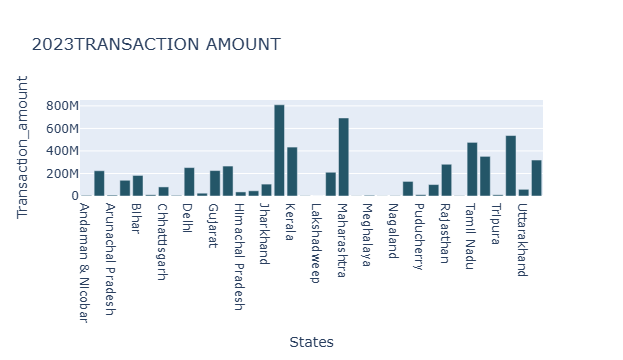

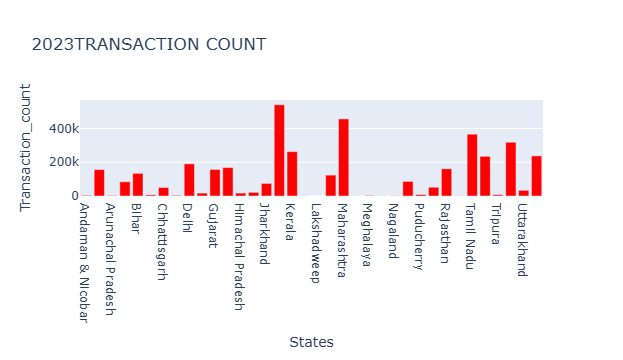

In [102]:
Transaction_amount_count_Y(aggre_insurance, 2023)

In [107]:
print(aggre_insurance.columns)

Index(['States', 'Years', 'Quarter', 'Insurance_type', 'Insurance_count',
       'Insurance_amount'],
      dtype='object')


In [110]:
aggre_insurance

,States,Years,Quarter,Insurance_type,Insurance_count,Insurance_amount
0,Andaman & Nicobar,2020,2,Insurance,6,1360.0
1,Andaman & Nicobar,2020,3,Insurance,41,15380.0
2,Andaman & Nicobar,2020,4,Insurance,124,157975.0
3,Andaman & Nicobar,2021,1,Insurance,225,244266.0
4,Andaman & Nicobar,2021,2,Insurance,137,181504.0
...,...,...,...,...,...,...
677,West Bengal,2023,4,Insurance,72712,100365562.0
678,West Bengal,2024,1,Insurance,79576,104987909.0
679,West Bengal,2024,2,Insurance,67048,89476633.0
680,West Bengal,2024,3,Insurance,77158,107451766.0


In [122]:
print(type(aggre_insurance))

<class 'pandas.core.frame.DataFrame'>
